In [ ]:
cimport tensorflow as tf
from tensorflow.keras.datasets import cifar10


(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


print("Training data shape:", X_train_full.shape)
print("Test data shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


 **the arch is :**  

- One input layer

- Two hidden layers: The first with 128 neurons and the second with 64 neurons, both using the ReLU activation function.

- One fully connected (output) layer: Using the Softmax activation function.


- Loss function: Cross-entropy.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Define the architecture
model = Sequential([
    # Input layer:
    # Flatten the 32x32x3 images into a 1D cause Multi-Layer Perceptron can only understand 1D array input
    Flatten(input_shape=(32, 32, 3)),

    # First hidden layer (128 neurons, ReLU)
    # remmber ReLU is  f(x) = max(0, x)
    Dense(128, activation='relu'),

    # Second hidden layer (64 neurons, ReLU)
    Dense(64, activation='relu'),

    # Output layer (10 neurons for the 10 CIFAR-10 classes, Softmax)
    Dense(10, activation='softmax')
])


model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

**why we use the validation set** : first its called called Model Selection or Hyperparameter Tuning,and there is two reason:
- To catch Overfitting (Early Stopping)
- To tweak the Hyperparameters

Starting training...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2456 - loss: 2.0856 - val_accuracy: 0.2950 - val_loss: 1.9550
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3253 - loss: 1.9036 - val_accuracy: 0.3349 - val_loss: 1.8742
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3559 - loss: 1.8348 - val_accuracy: 0.3618 - val_loss: 1.8049
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3747 - loss: 1.7838 - val_accuracy: 0.3696 - val_loss: 1.7723
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3882 - loss: 1.7446 - val_accuracy: 0.3725 - val_loss: 1.7819
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3979 - loss: 1.7169 - val_accuracy: 0.3878 - val_loss: 1.7159
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4075 - loss: 1.6891 - val_accuracy: 0.3996 - val_loss: 1.6801
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4155 - loss: 1.6

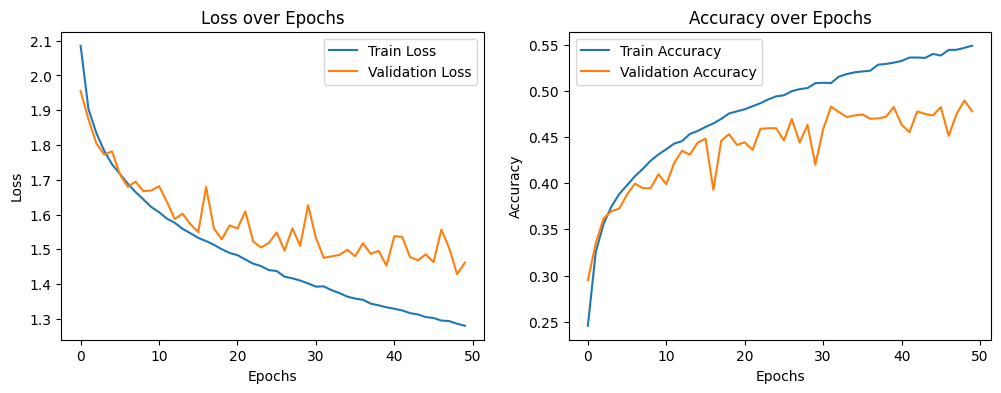

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD

# We use 'sparse_categorical_crossentropy' because our labels are single integers (0-9) not an array of 0s and 1s like One-Hot Encoding
model.compile(optimizer=SGD(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



print("Starting training...")
history = model.fit(X_train, y_train,
                    batch_size=128,
                    epochs=50,
                    validation_data=(X_valid, y_valid))

# 3. Plotingg
plt.figure(figsize=(12, 4))

#  Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()


 1. LOSS GRAPH (Left):
   - Both Train and Validation loss drop initially but plateau around ~1.2.
  - Validation loss decreases but oscillates heavily The model hasn't fully generalized .
  - after the epochs 30 we can see that the gap between them is getting bigger and that sign of overfitting

 2. ACCURACY GRAPH (Right):
  - Both Train and Validation accuracy get stuck at roughly 55% (~0.55).
  - Diagnosis: The model is hitting its "capacity." A standard MLP that
   flattens images loses spatial relationships (shapes/edges), making it
   too simple to fully master the complex color images of CIFAR-10.
   The model is underfitting the complexity of the data.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting training with L2 Regularization...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2725 - loss: 2.8906 - val_accuracy: 0.3112 - val_loss: 2.7148
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3379 - loss: 2.6088 - val_accuracy: 0.3315 - val_loss: 2.5481
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3612 - loss: 2.4676 - val_accuracy: 0.3480 - val_loss: 2.4304
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3744 - loss: 2.3585 - val_accuracy: 0.3690 - val_loss: 2.3216
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3866 - loss: 2.2646 - val_accuracy: 0.3823 - val_loss: 2.2358
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3979 - loss: 2.1845 - val_accuracy: 0.3973 - val_loss: 2.1671
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4047 - loss: 2.1147 - val_accuracy: 0.3876 - val_loss: 2.1097
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accura

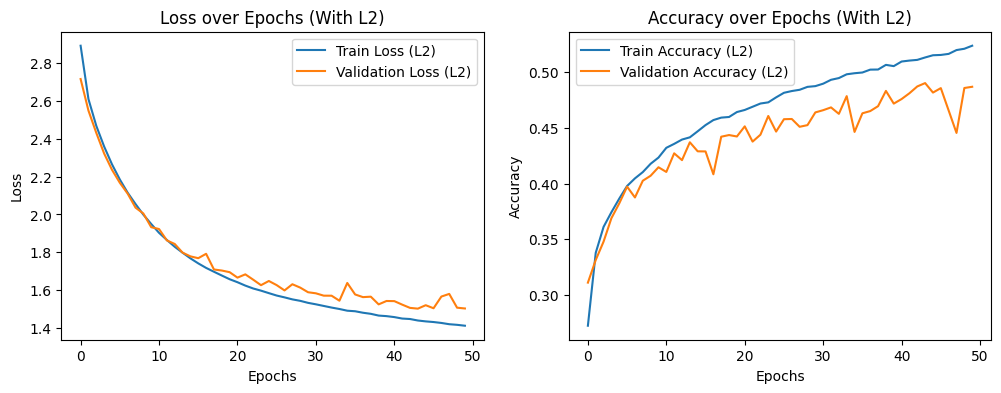

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt


model_l2 = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'), # First hidden layer (no L2)

    # Second hidden layer WITH L2 Regularization
    # 0.01  Regularization Strength (often called Lambda) is a standard default strength for the penalty
    #too big => becomes terrified to learn anything
    #too small => penalty is too small, the network basically ignores it
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),

    Dense(10, activation='softmax')
])

model_l2.compile(optimizer=SGD(learning_rate=0.01),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Starting training with L2 Regularization...")
history_l2 = model_l2.fit(X_train, y_train,
                          batch_size=128,
                          epochs=50,
                          validation_data=(X_valid, y_valid))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_l2.history['loss'], label='Train Loss (L2)')
plt.plot(history_l2.history['val_loss'], label='Validation Loss (L2)')
plt.title('Loss over Epochs (With L2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_l2.history['accuracy'], label='Train Accuracy (L2)')
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy (L2)')
plt.title('Accuracy over Epochs (With L2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Regularization is the set of techniques we use to stop the network from memorizing. It forces the model to learn simpler, broader patterns that generalize well to the real world
- L1 Regularization => force the weights of less important features to become exactly zer
- L2 Regularization =>It stops any single feature from having too much power, resulting in a much smoother, more balanced model

**notes**:
```
Without L2:  Train=0.55,  Val=0.49  → gap = 0.06
With L2:     Train=0.52,  Val=0.49  → gap = 0.03
```
we that the L2 reduced the gap by penalizing the training side
and we know that L2 is most effective when: Train accuracy >> Val accuracy (strong overfitting). in our  case: moderate overfitting → L2 gives only marginal gain.

- why the accuracy does not change so much => cause the problem is not mainly overfitting , its more about underfitting (the model capacity is the bottleneck )
-Train loss is intentionally higher cause The model is forced to keep weights small, which slightly hurts training performance.


--- Training model with Dropout Rate: 0.2 ---
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2230 - loss: 2.1123 - val_accuracy: 0.2864 - val_loss: 1.9803
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2901 - loss: 1.9604 - val_accuracy: 0.3226 - val_loss: 1.8940
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3176 - loss: 1.8919 - val_accuracy: 0.3359 - val_loss: 1.8466
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3364 - loss: 1.8503 - val_accuracy: 0.3560 - val_loss: 1.8033
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3499 - loss: 1.8182 - val_accuracy: 0.3752 - val_loss: 1.7674
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3623 - loss: 1.7926 - val_accuracy: 0.3801 - val_loss: 1.7498
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3722 - loss: 1.7645 - val_accuracy: 0.3935 - val_loss: 1.7132
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc

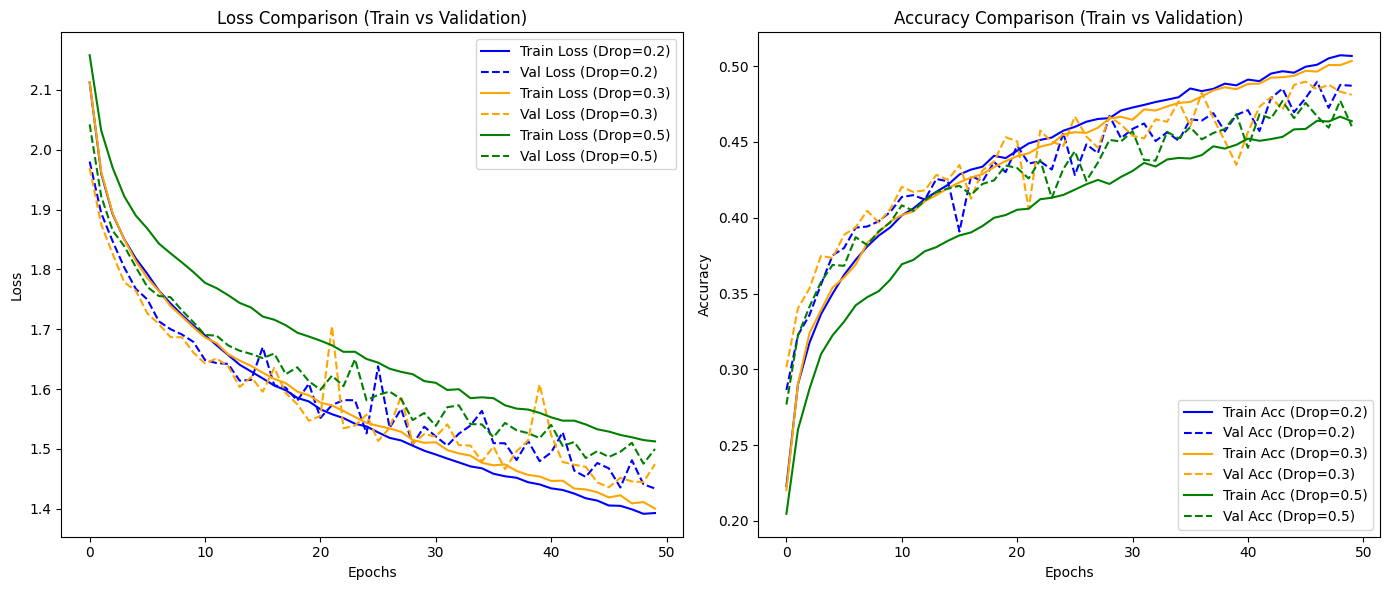

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

dropout_rates = [0.2, 0.3, 0.5]

histories_dropout = {}

for rate in dropout_rates:
    print(f"\n--- Training model with Dropout Rate: {rate} ---")


    model_drop = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dropout(rate),                      # <-- DROPOUT APPLIED HERE
        Dense(10, activation='softmax')
    ])


    model_drop.compile(optimizer=SGD(learning_rate=0.01),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

    history = model_drop.fit(X_train, y_train,
                             batch_size=128,
                             epochs=50,
                             validation_data=(X_valid, y_valid),
                             verbose=1)


    histories_dropout[rate] = history

# 4. Plotting the Comparison (Train AND Validation)
plt.figure(figsize=(14, 6))

# Define colors so Train and Val match for each rate
colors = {0.2: 'blue', 0.3: 'orange', 0.5: 'green'}

# --- Plot Loss ---
plt.subplot(1, 2, 1)
for rate in dropout_rates:
    # Train Loss (Solid line)
    plt.plot(histories_dropout[rate].history['loss'],
             label=f'Train Loss (Drop={rate})',
             color=colors[rate], linestyle='solid')
    # Validation Loss (Dashed line)
    plt.plot(histories_dropout[rate].history['val_loss'],
             label=f'Val Loss (Drop={rate})',
             color=colors[rate], linestyle='dashed')

plt.title('Loss Comparison (Train vs Validation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
for rate in dropout_rates:
    # Train Accuracy (Solid line)
    plt.plot(histories_dropout[rate].history['accuracy'],
             label=f'Train Acc (Drop={rate})',
             color=colors[rate], linestyle='solid')
      # Validation Accuracy (Dashed line)
    plt.plot(histories_dropout[rate].history['val_accuracy'],
             label=f'Val Acc (Drop={rate})',
             color=colors[rate], linestyle='dashed')

plt.title('Accuracy Comparison (Train vs Validation)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Dropout is a radically simple but highly effective technique. During training, you randomly "drop out" (turn off) a percentage of the neurons in the network on every single pass. to forces the network to distribute the learning across the entire structure

Starting training with Early Stopping...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2691 - loss: 2.0223 - val_accuracy: 0.2607 - val_loss: 1.9713
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3419 - loss: 1.8579 - val_accuracy: 0.3385 - val_loss: 1.8362
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3659 - loss: 1.7936 - val_accuracy: 0.3599 - val_loss: 1.7916
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3852 - loss: 1.7470 - val_accuracy: 0.3780 - val_loss: 1.7413
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3974 - loss: 1.7116 - val_accuracy: 0.3855 - val_loss: 1.7200
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4072 - loss: 1.6804 - val_accuracy: 0.3861 - val_loss: 1.7274
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4186 - loss: 1.6556 - val_accuracy: 0.4088 - val_loss: 1.6721
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy:

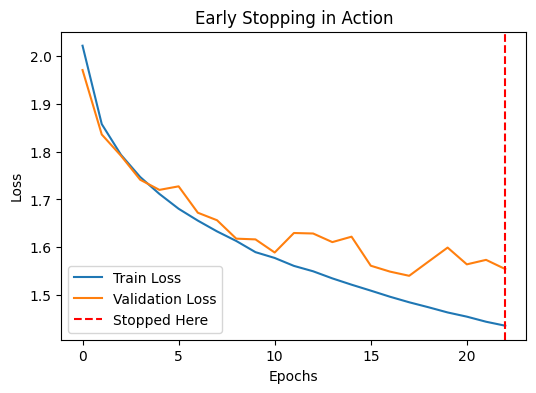

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model_es = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_es.compile(optimizer=SGD(learning_rate=0.01),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 2. Define the Early Stopping Callback
# monitor='val_loss': We want it to watch the validation loss curve.
# patience=5: If the val_loss doesn't improve for 5 epochs in a row, stop training!
# restore_best_weights=True: This is CRUCIAL. It rolls the model back to its best state.
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

# 3. Train the model and pass the callback
print("Starting training with Early Stopping...")
history_es = model_es.fit(X_train, y_train,
                          batch_size=128,
                          epochs=50, # We still tell it 50, but it won't reach it
                          validation_data=(X_valid, y_valid),
                          callbacks=[early_stopping]) # <-- Callback added here

# 4. Find and print the exact epoch it stopped at
# The history dictionary only saves data for the epochs that actually ran
total_epochs_run = len(history_es.history['loss'])
print(f"\n====================================================")
print(f" Training automatically stopped after {total_epochs_run} epochs.")
print(f"====================================================")

# Optional: Plot to see where it cut off
plt.figure(figsize=(6, 4))
plt.plot(history_es.history['loss'], label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Validation Loss')
plt.axvline(x=total_epochs_run-1, color='red', linestyle='--', label='Stopped Here')
plt.title('Early Stopping in Action')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Starting training with Batch Normalization...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3262 - loss: 1.9191 - val_accuracy: 0.3387 - val_loss: 1.8368
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3992 - loss: 1.7106 - val_accuracy: 0.3991 - val_loss: 1.7151
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4260 - loss: 1.6354 - val_accuracy: 0.4080 - val_loss: 1.6667
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4487 - loss: 1.5809 - val_accuracy: 0.4226 - val_loss: 1.6314
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4643 - loss: 1.5395 - val_accuracy: 0.4254 - val_loss: 1.6069
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4757 - loss: 1.5040 - val_accuracy: 0.4279 - val_loss: 1.6286
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4868 - loss: 1.4762 - val_accuracy: 0.4331 - val_loss: 1.5999
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accu

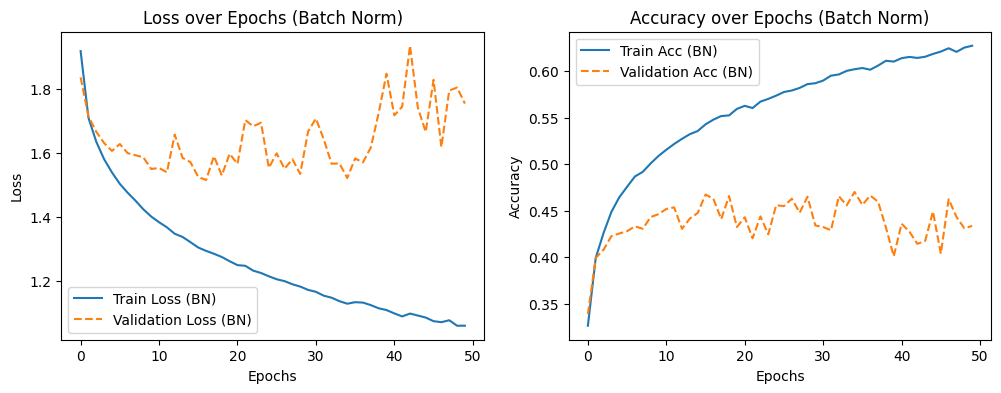

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# 1. Define the architecture with Batch Normalization
model_bn = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),  # First hidden layer
    BatchNormalization(),           # <-- BATCH NORMALIZATION ADDED HERE
    Dense(64, activation='relu'),   # Second hidden layer
    Dense(10, activation='softmax') # Output layer
])

# 2. Compile the model
model_bn.compile(optimizer=SGD(learning_rate=0.01),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 3. Train the model using Mini-batch SGD (batch_size=128)
print("Starting training with Batch Normalization...")
history_bn = model_bn.fit(X_train, y_train,
                          batch_size=128,
                          epochs=50,
                          validation_data=(X_valid, y_valid))

# 4. Plot the learning curves
plt.figure(figsize=(12, 4))

# Plot the Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_bn.history['loss'], label='Train Loss (BN)', linestyle='solid')
plt.plot(history_bn.history['val_loss'], label='Validation Loss (BN)', linestyle='dashed')
plt.title('Loss over Epochs (Batch Norm)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot the Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_bn.history['accuracy'], label='Train Acc (BN)', linestyle='solid')
plt.plot(history_bn.history['val_accuracy'], label='Validation Acc (BN)', linestyle='dashed')
plt.title('Accuracy over Epochs (Batch Norm)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the search space (the "menu" of options)
learning_rates = [0.001, 0.01, 0.1]
dropout_rates = [0.2, 0.3, 0.4, 0.5]
batch_sizes = [32, 64, 128, 256]

# Define how many random combinations we want to test
num_trials = 5

best_val_accuracy = 0
best_params = {}

print(f"Starting Random Search for {num_trials} combinations...\n")

# 2. The Random Search Loop
for trial in range(num_trials):
    # Randomly select one value from each list
    lr = random.choice(learning_rates)
    drop = random.choice(dropout_rates)
    batch = random.choice(batch_sizes)

    print(f"--- Trial {trial+1}/{num_trials} ---")
    print(f"Testing: LR={lr}, Dropout={drop}, Batch={batch}")

    # 3. Build the model with the selected random parameters
    model_rs = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(128, activation='relu'),
        BatchNormalization(),           # Kept from Question 8
        Dense(64, activation='relu'),
        Dropout(drop),                  # Our random dropout rate
        Dense(10, activation='softmax')
    ])

    # Compile with our random learning rate
    model_rs.compile(optimizer=SGD(learning_rate=lr),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

    # Use Early Stopping to quickly kill bad combinations
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # 4. Train the model (verbose=0 hides the progress bar so your screen isn't flooded)
    history = model_rs.fit(X_train, y_train,
                           batch_size=batch,      # Our random batch size
                           epochs=20,             # Shortened max epochs for faster searching
                           validation_data=(X_valid, y_valid),
                           callbacks=[early_stopping],
                           verbose=0)

    # 5. Record the results
    val_acc = max(history.history['val_accuracy'])
    print(f"Result -> Best Validation Accuracy: {val_acc:.4f}\n")

    # If this is the highest score we've seen, save it!
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_params = {'learning_rate': lr, 'dropout_rate': drop, 'batch_size': batch}

# 6. Print the final winner
print("====================================================")
print(f"🏆 BEST PARAMETERS FOUND:")
print(f"Learning Rate: {best_params['learning_rate']}")
print(f"Dropout Rate:  {best_params['dropout_rate']}")
print(f"Batch Size:    {best_params['batch_size']}")
print(f"Best Val Acc:  {best_val_accuracy:.4f}")
print("====================================================")

Starting Random Search for 5 combinations...

--- Trial 1/5 ---
Testing: LR=0.01, Dropout=0.2, Batch=128
Result -> Best Validation Accuracy: 0.4641

--- Trial 2/5 ---
Testing: LR=0.001, Dropout=0.5, Batch=64
Result -> Best Validation Accuracy: 0.4257

--- Trial 3/5 ---
Testing: LR=0.001, Dropout=0.5, Batch=32
Result -> Best Validation Accuracy: 0.4311

--- Trial 4/5 ---
Testing: LR=0.1, Dropout=0.3, Batch=128
Result -> Best Validation Accuracy: 0.4103

--- Trial 5/5 ---
Testing: LR=0.01, Dropout=0.3, Batch=128
Result -> Best Validation Accuracy: 0.4560

🏆 BEST PARAMETERS FOUND:
Learning Rate: 0.01
Dropout Rate:  0.2
Batch Size:    128
Best Val Acc:  0.4641
